<a href="https://colab.research.google.com/github/asdsadawww/-/blob/main/%EC%9D%B8%ED%84%B0%EB%A0%89%ED%8B%B0%EB%B8%8C_%EA%B7%B8%EB%9E%98%ED%94%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
mpg=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/mpg.csv')

In [3]:
px.scatter(data_frame=mpg,x='cty',y='hwy',color='drv')     #산점도만들기, 드래그해서 영역지정가능, 더블클릭으로 복구

In [4]:
df=mpg.groupby('class',as_index=False).agg(n=('class','count'))       #category -> class로 변경, 자동차 종류별 빈도 구하기
df

,class,n
0,2seater,5
1,compact,47
2,midsize,41
3,minivan,11
4,pickup,33
5,subcompact,35
6,suv,62


In [5]:
px.bar(data_frame=df,x='class',y='n',color='class')  #막대그래프 만들기

In [6]:
economics=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/economics.csv')
px.line(data_frame=economics,x='date',y='psavert')        #선 그래프 만들기

In [7]:
px.box(data_frame=mpg,x='drv',y='hwy',color='drv')     #상자그림만들기

#데이터 분석
##마크다운
문자 앞뒤에 *특수문자*를 넣으면 기울임체가 된다

문자 앞뒤에 **특수문자**를 넣으면 강조체가 된다

문자 앞뒤에 ~~특수문자~~를 넣으면 취소선이 된다

문자 앞뒤에 [특수문자](http://www.google.com/search?q=special+character)를 넣으면 하이퍼링크를 만든다

코드에 백틱기호를 입력하면 `pandas`와 같이 음영을 넣는다

# 데이터 분석 보고서 만들기

## 마크다운

마크다운 문법으로 코드를 작성해 [HTML](http://ko.wikipedia.org/wiki/HTML)로 변환 할 수 있습니다. 마크다운을 이용하면 분석 과정과 결과를 자세하게 기술할 수 있어서 **재현 가능성**을 갖춘 *데이터 분석 보고서*를 만들 수 있습니다.

### 마크다운 문법 예제

코드와 코드 실행 결과물을 보고서에 함께 출력합니다.

In [8]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/mpg.csv')
df['drv'].value_counts()

,count
drv,
f,106
4,103
r,25


<Axes: xlabel='drv', ylabel='count'>

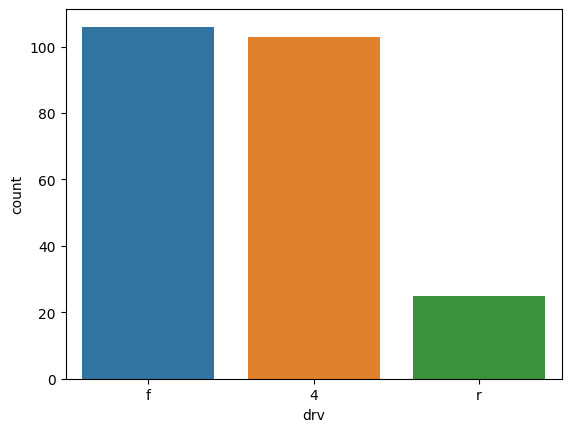

In [9]:
sns.countplot(data=df,x='drv',hue='drv')

In [20]:
mpg=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/mpg.csv')
mpg = mpg.rename(columns={'class': 'category'})
mpg.query('category in ["compact","suv"]').groupby('category',as_index=False).agg(n =('category','count'),mean =('cty','mean'))
          #compact, suv 추출하기                  #category별 분리하기           #빈도 구하기                  #cty평균 구하기

,category,n,mean
0,compact,47,20.12766
1,suv,62,13.50000


In [21]:
compact=mpg.query('category == "compact"')['cty']
suv=mpg.query('category=="suv"')['cty']

In [23]:
from scipy import stats
stats.ttest_ind(compact, suv, equal_var=True)                   #t-test(t 검정은 두 집단의 평군에 통계적으로 유의한 차이가 있는지 알아볼 때 사용하는 통계 분석 기법)
#이 분석 결과는 pvalue가  0.05보다 작기 때문에 'compact와 suv 간 평균 도시 연비 차이가 통계적으로 유의미하다'라고 결론내릴 수 있다

TtestResult(statistic=np.float64(11.917282584324107), pvalue=np.float64(2.3909550904711282e-21), df=np.float64(107.0))

In [24]:
mpg.query('fl in ["r","p"]').groupby('fl', as_index=False).agg(n =('fl','count'),mean=('cty','mean'))
         #r, p 추출하기            #fl별 분리                 #빈도 구하기            #cty 평균 구하기

,fl,n,mean
0,p,52,17.365385
1,r,168,16.738095


In [25]:
regular=mpg.query('fl=="r"')['cty']
premium=mpg.query('fl=="p"')['cty']
stats.ttest_ind(regular, premium, equal_var=True)           #t-test

TtestResult(statistic=np.float64(-1.066182514588919), pvalue=np.float64(0.28752051088667036), df=np.float64(218.0))

In [26]:
economics=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/economics.csv')
economics[['unemploy','pce']].corr()          #상관행렬 만들기

,unemploy,pce
unemploy,1.000000,0.614518
pce,0.614518,1.000000


In [27]:
stats.pearsonr(economics['unemploy'],economics['pce'])           #상관분

PearsonRResult(statistic=np.float64(0.614517614193208), pvalue=np.float64(6.773527303290071e-61))

In [28]:
mtcars=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/mtcars.csv')
mtcars.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [30]:
mtcars = mtcars.set_index('model')
car_cor=mtcars.corr()          #상관행렬 만들기
car_cor=round(car_cor,2)       #소수점 둘째 자리까지 반올림
car_cor

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.00,-0.85,-0.85,-0.78,0.68,-0.87,0.42,0.66,0.60,0.48,-0.55
cyl,-0.85,1.00,0.90,0.83,-0.70,0.78,-0.59,-0.81,-0.52,-0.49,0.53
disp,-0.85,0.90,1.00,0.79,-0.71,0.89,-0.43,-0.71,-0.59,-0.56,0.39
hp,-0.78,0.83,0.79,1.00,-0.45,0.66,-0.71,-0.72,-0.24,-0.13,0.75
drat,0.68,-0.70,-0.71,-0.45,1.00,-0.71,0.09,0.44,0.71,0.70,-0.09
wt,-0.87,0.78,0.89,0.66,-0.71,1.00,-0.17,-0.55,-0.69,-0.58,0.43
qsec,0.42,-0.59,-0.43,-0.71,0.09,-0.17,1.00,0.74,-0.23,-0.21,-0.66
vs,0.66,-0.81,-0.71,-0.72,0.44,-0.55,0.74,1.00,0.17,0.21,-0.57
am,0.60,-0.52,-0.59,-0.24,0.71,-0.69,-0.23,0.17,1.00,0.79,0.06
gear,0.48,-0.49,-0.56,-0.13,0.70,-0.58,-0.21,0.21,0.79,1.00,0.27


In [31]:
plt.rcParams.update({'figure.dpi'    :'120',                    #해상도 설정
                     'figure.figsize':[7.5, 5.5]})              #가로 세로 크기 설정

<Axes: >

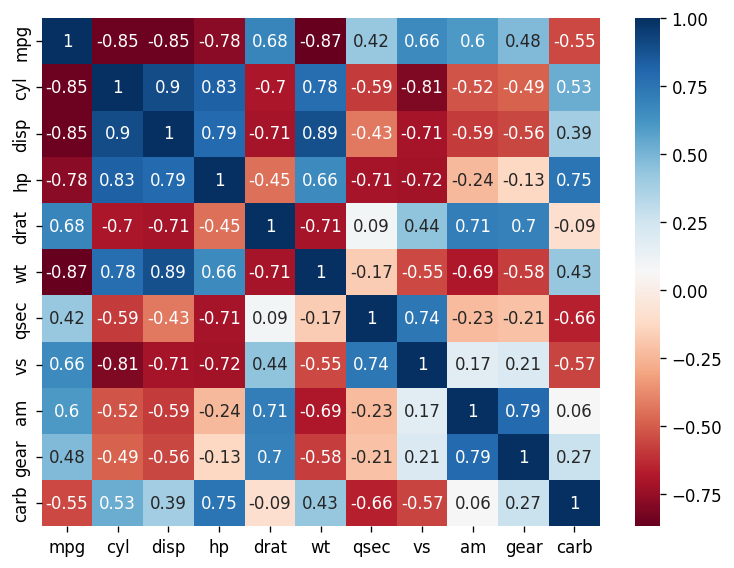

In [32]:
sns.heatmap(car_cor, annot= True,     #상관계수 표시
            cmap='RdBu')              #컬러

In [33]:
mask=np.zeros_like(car_cor)
mask                                    #mask만들기

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [34]:
mask[np.triu_indices_from(mask)]=1
mask                                   #오른쪽 위 대각행렬을 1로 바꾸기

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

<Axes: >

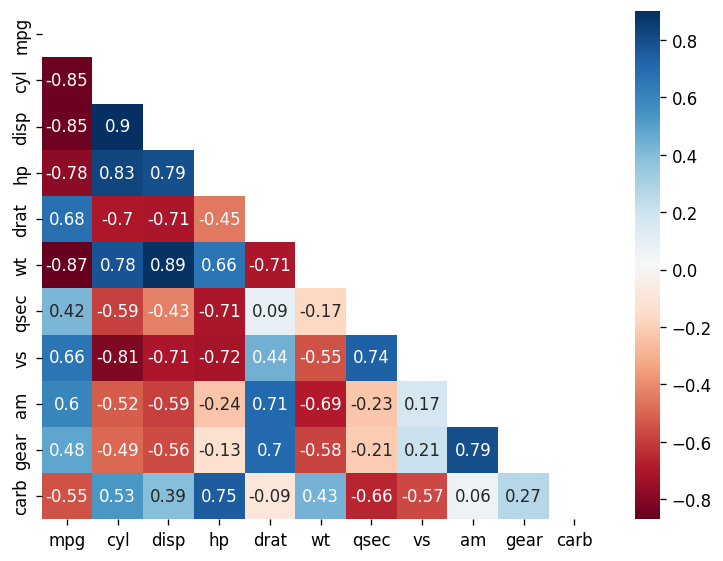

In [35]:
sns.heatmap(data=car_cor,
            annot=True,     #상관계수 표시
            cmap='RdBu',    #컬러맵
            mask=mask)      #mask적용으로 인해 1표시 된 부분을 제외하고 출력

<Axes: >

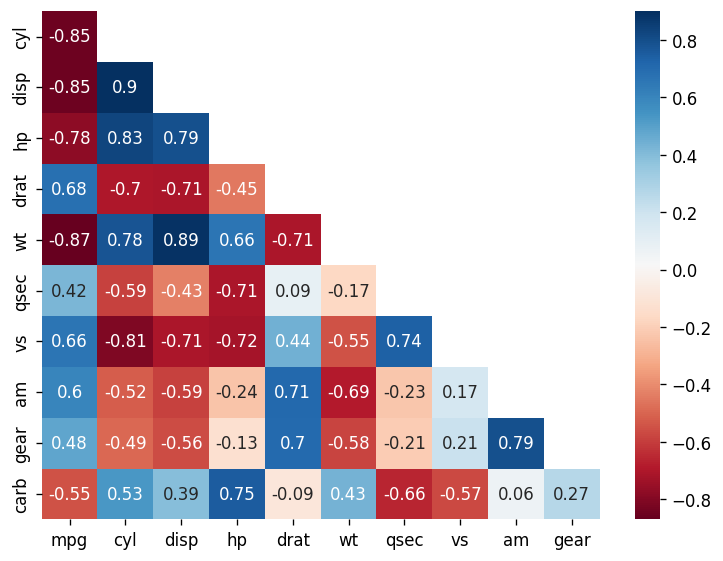

In [37]:
mask_new=mask[1:, :-1]          #mask 첫 번째 행, 마지막 열 제거
cor_new=car_cor.iloc[1:, :-1]   #상관행렬 첫 번째 행, 마지막 열 제거
sns.heatmap(data=cor_new,
            annot=True,      #상관계수 표시
            cmap='RdBu',     #컬러맵
            mask=mask_new)   #mask 적용

<Axes: >

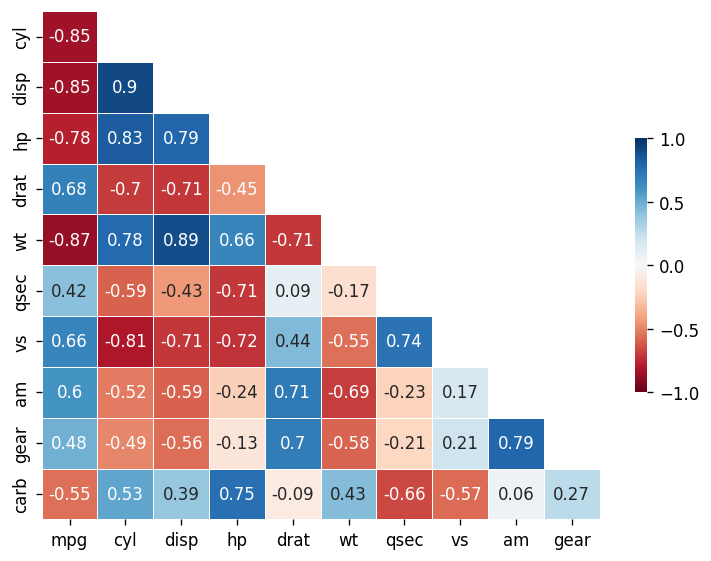

In [38]:
sns.heatmap(data=cor_new,
            annot=True,              #상관계수 표시
            cmap='RdBu',             #컬러맵
            mask=mask_new,           #mask적용
            linewidths =.5,          #경계 구분선 추가
            vmax=1,                  #가장 진한 파란색으로 표현할 최대값
            vmin=-1,                 #가장 진한 빨간색으로 표현할 최소값
            cbar_kws={'shrink':.5})  #범례 크기 줄이기